# 1数据加载和分析

In [ ]:
from sklearn.datasets import fetch_20newsgroups
import os

# os.environ['http_proxy'] = ''
# os.environ['https_proxy'] = ''
# os.environ['SCIKIT_LEARN_DATA'] = '~/scikit_learn_data/'

# 加载数据集
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories)
newsgroups_test = fetch_20newsgroups(subset='test', categories=categories)

sample = {
    "text_preview": newsgroups_train.data[0],
    "category": newsgroups_train.target[0]
}

print(sample)


{'text_preview': 'From: sd345@city.ac.uk (Michael Collier)\nSubject: Converting images to HP LaserJet III?\nNntp-Posting-Host: hampton\nOrganization: The City University\nLines: 14\n\nDoes anyone know of a good way (standard PC application/PD utility) to\nconvert tif/img/tga files into LaserJet III format.  We would also like to\ndo the same, converting to HPGL (HP plotter) files.\n\nPlease email any response.\n\nIs this the correct group?\n\nThanks in advance.  Michael.\n-- \nMichael Collier (Programmer)                 The Computer Unit,\nEmail: M.P.Collier@uk.ac.city                The City University,\nTel: 071 477-8000 x3769                      London,\nFax: 071 477-8565                            EC1V 0HB.\n', 'category': 1}


['hello', ',', 'world', '!']


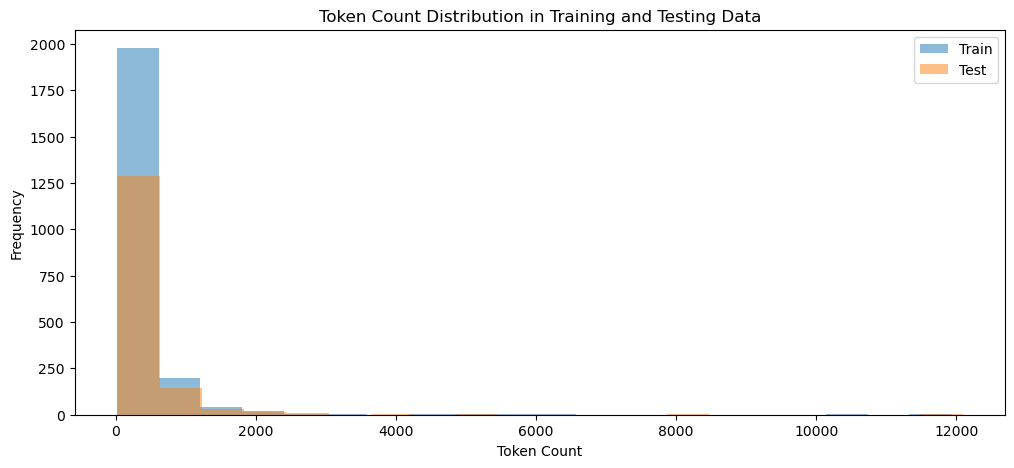

In [2]:
import re
import matplotlib.pyplot as plt

# 训练集和测试集数据长度分布

def basic_tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9(),.!?\'`]", " ", text) # 将非字母、数字、标点符号、引号等字符替换为空格
    text = re.sub(r"([,.!?\'`])", r" \1 ", text) # 将标点符号前后添加空格
    return text.strip().split() # 返回一个列表，列表中的每个元素是一个单词

print(basic_tokenize("Hello,  world!"))

train_lengths = [len(basic_tokenize(text)) for text in newsgroups_train.data]
test_lengths = [len(basic_tokenize(text)) for text in newsgroups_test.data]

# 绘制训练集和测试集数据长度分布
plt.figure(figsize=(12, 5))
plt.hist(train_lengths, bins=20, alpha=0.5, label='Train')
plt.hist(test_lengths, bins=20, alpha=0.5, label='Test')
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.title('Token Count Distribution in Training and Testing Data')
plt.legend()
plt.show()

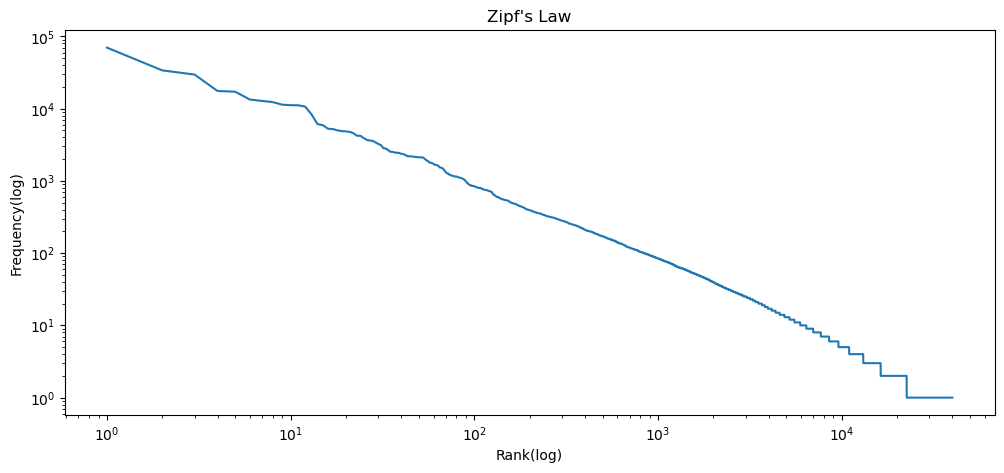

In [3]:
from collections import Counter

word_counts = Counter()

for text in newsgroups_train.data:
    words = basic_tokenize(text)
    word_counts.update(words)

frequencies = sorted(word_counts.values(), reverse=True)

ranks = range(1, len(frequencies) + 1)

plt.figure(figsize=(12, 5))
plt.loglog(ranks, frequencies) # 对数坐标轴
plt.xlabel('Rank(log)')
plt.ylabel('Frequency(log)')
plt.title('Zipf\'s Law')
plt.show()


# 2定义所需组件

In [4]:
class Tokenizer:
    def __init__(self, vocab):
        self.token_to_id = vocab
        self.id_to_token = list(vocab.keys())

    def encode(self, text):
        return [self.token_to_id.get(word, self.token_to_id['<unk>']) for word in basic_tokenize(text)]
    
    def decode(self, indices):
        return ' '.join([self.id_to_token[index] for index in indices])
    
    def __len__(self):
        return len(self.token_to_id)
    
    def __getitem__(self, word):
        return self.token_to_id.get(word, self.token_to_id['<unk>'])
        

In [5]:
def build_vocab(word_counts, min_freq=5):
    vocab = {"<pad>": 0, "<unk>": 1}
    
    for word, freq in word_counts.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
            
    return vocab

tokenizer = Tokenizer(build_vocab(word_counts))
print(len(tokenizer))
print(tokenizer.encode("hello, world!"))
print(tokenizer.decode([375, 46, 995, 364]))

# 3 数据预处理




10983
[375, 46, 995, 364]
hello , world !


In [6]:
from torch.utils.data import Dataset
from tqdm import tqdm

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.processed_data = []
        for text, label in tqdm(zip(texts, labels), total=len(texts)):
            tokens = tokenizer.encode(text)
            if len(tokens) <= max_length:
                self.processed_data.append((tokens, label))
            else:
                stride = max(1, int(max_length * 0.8))
                for i in range(0, len(tokens)-max_length+1, stride):
                    chunk = tokens[i:i+max_length]
                    self.processed_data.append((chunk, label))

    def __len__(self):
        return len(self.processed_data)
    
    def __getitem__(self, index):
        return self.processed_data[index]

In [7]:
import torch

def collate_fn(batch):
    tokens = [torch.tensor(item[0]) for item in batch]
    labels = [item[1] for item in batch]
    tokens = torch.nn.utils.rnn.pad_sequence(tokens, batch_first=True, padding_value=tokenizer['<pad>'])
    labels = torch.tensor(labels)
    return {
        "input_ids": tokens,    
        "labels": labels
    }

print(collate_fn([([1, 2, 3, 12, 15], 0), ([4, 5, 6], 1)]))


{'input_ids': tensor([[ 1,  2,  3, 12, 15],
        [ 4,  5,  6,  0,  0]]), 'labels': tensor([0, 1])}


In [8]:
from torch.utils.data import DataLoader

train_dataset = TextDataset(newsgroups_train.data, newsgroups_train.target, tokenizer)
test_dataset = TextDataset(newsgroups_test.data, newsgroups_test.target, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

batch1 = next(iter(train_loader))
print(len(train_dataset))
print(len(test_dataset))
print(batch1)

100%|██████████| 1502/1502 [00:00<00:00, 3700.18it/s]

7142
5408
{'input_ids': tensor([[   1,   46,  285,  ...,    4,  113,  311],
        [   2,  789,  149,  ...,  652,    4,   20],
        [5410, 5296,   46,  ..., 4206,    4,  129],
        ...,
        [ 129,    4,   20,  ..., 3384,   27,   20],
        [   1,  138,  713,  ...,    4,  366,    4],
        [  90,  873,  108,  ...,  113,  129,    4]]), 'labels': tensor([1, 2, 2, 0, 2, 2, 3, 2, 3, 2, 3, 0, 2, 3, 0, 0, 1, 3, 2, 3, 3, 3, 3, 3,
        1, 1, 2, 2, 0, 2, 1, 1])}


# 3模型构建

In [9]:
import torch.nn as nn
import torch.optim as optim

class TextClassificationModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes):
        super(TextClassificationModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=tokenizer['<pad>'])
        
        self.feature_extractor = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim * 2),
            nn.ReLU(),
            nn.Linear(hidden_dim * 2, embedding_dim * 4),
            nn.ReLU(),
        )

        self.fc = nn.Linear(embedding_dim * 4, num_classes)
        
    def forward(self, input_ids):
        # input_ids: [batch_size, seq_length]
        # embedded: [batch_size, seq_length, embedding_dim]
        embedded = self.embedding(input_ids)
        features = self.feature_extractor(embedded)
        
        pading_mask = (input_ids != tokenizer['<pad>']).float() # 创建一个掩码，用于屏蔽填充的token
        features = features * pading_mask.unsqueeze(-1) # 将掩码应用到特征上
        features = features.sum(dim=1) / torch.clamp(pading_mask.sum(dim=1, keepdim=True), min=1) #  对特征进行归一化
        
        return self.fc(features)
    

In [10]:
import os
import json

class Trainer:
    def __init__(self, model, optimizer, lr_scheduler,criterion, train_loader, valid_loader, device, output_dir="."):
        self.model = model
        self.optimizer = optimizer
        self.lr_scheduler = lr_scheduler
        self.criterion = criterion
        self.train_loader = train_loader
        self.valid_loader = valid_loader
        self.device = device
        self.best_accuracy = 0.0
        self.output_dir = output_dir
        os.makedirs(self.output_dir, exist_ok=True)
        self.train_losses = []
        self.val_accuracies = []

    def _run_epoch(self, epoch):
        self.model.train()
        total_loss = 0
        for batch in tqdm(self.train_loader, desc=f"Epoch {epoch+1} [训练中]"):
            self.optimizer.zero_grad()
            
            input_ids = batch["input_ids"].to(self.device)
            labels = batch["labels"].to(self.device)
            
            outputs = self.model(input_ids)
            loss = self.criterion(outputs, labels)
            total_loss += loss.item()
            
            loss.backward()
            self.optimizer.step()
        
        return total_loss / len(self.train_loader)

    def _evaluate(self, epoch):
        self.model.eval()
        correct_preds = 0
        total_samples = 0
        with torch.no_grad():
            for batch in tqdm(self.valid_loader, desc=f"Epoch {epoch+1} [评估中]"):
                input_ids = batch["input_ids"].to(self.device)
                labels = batch["labels"].to(self.device)
                
                outputs = self.model(input_ids)
                _, predicted = torch.max(outputs, 1)
                
                total_samples += labels.size(0)
                correct_preds += (predicted == labels).sum().item()
        
        return correct_preds / total_samples

    def _save_checkpoint(self, epoch, val_accuracy):
        if val_accuracy > self.best_accuracy:
            self.best_accuracy = val_accuracy
            save_path = os.path.join(self.output_dir, "best_model.pth")
            torch.save(self.model.state_dict(), save_path)
            print(f"新最佳模型已保存! Epoch: {epoch+1}, 验证集准确率: {val_accuracy:.4f}")

    def train(self, epochs, tokenizer, label_map):
        self.train_losses = []
        self.val_accuracies = []
        for epoch in range(epochs):
            avg_loss = self._run_epoch(epoch)
            val_accuracy = self._evaluate(epoch)
            
            self.train_losses.append(avg_loss)
            self.val_accuracies.append(val_accuracy)

            print(f"Epoch {epoch+1}/{epochs} | 训练损失: {avg_loss:.4f} | 验证集准确率: {val_accuracy:.4f}")
            
            self._save_checkpoint(epoch, val_accuracy)
            # self.lr_scheduler.step()  # 每 epoch 一次，StepLR.step_size 才表示「每 N 个 epoch」
        
        print("训练完成！")
        vocab_path = os.path.join(self.output_dir, 'vocab.json')
        with open(vocab_path, 'w', encoding='utf-8') as f:
           json.dump(tokenizer.token_to_id, f, ensure_ascii=False, indent=4)
           
        labels_path = os.path.join(self.output_dir, 'label_map.json')
        with open(labels_path, 'w', encoding='utf-8') as f:
           json.dump(label_map, f, ensure_ascii=False, indent=4)
        print(f"词典 ({vocab_path}) 和标签映射 ({labels_path}) 已保存。")
        return self.train_losses, self.val_accuracies

In [11]:
class Predictor:
    def __init__(self, model, tokenizer, label_map, device, max_len=128):
        self.model = model.to(device)
        self.model.eval()
        self.tokenizer = tokenizer
        self.label_map = label_map
        self.id_to_label = {idx: label for label, idx in self.label_map.items()}
        self.device = device
        self.max_len = max_len

    def predict(self, text):
        input_ids = self.tokenizer.encode(text)
        chunks = []
        if len(input_ids) <= self.max_len:
            chunks.append(input_ids)
        else:
            stride = max(1, int(self.max_len * 0.8))
            for i in range(0, len(input_ids) - self.max_len + 1, stride):
                chunks.append(input_ids[i:i + self.max_len])
        
        chunk_tensors = torch.tensor(chunks, dtype=torch.long).to(self.device)
        with torch.no_grad():
            outputs = self.model(chunk_tensors)
            preds = torch.argmax(outputs, dim=1)

        final_pred_id = torch.bincount(preds).argmax().item() # 使用bincount统计每个预测类别的数量，然后选择数量最多的类别作为最终预测类别
        
        final_pred_label = self.id_to_label[final_pred_id]
        return final_pred_label

# 4模型训练

In [12]:
hparams = {
    "vocab_size": len(tokenizer),
    "embedding_dim": 128,
    "hidden_dim": 256,
    "num_classes": len(categories),
    "learning_rate": 0.001,
    "epoch": 20,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "output_dir": "output_01"
}

label_map = {name: i for i, name in enumerate(newsgroups_train.target_names)}

model = TextClassificationModel(
    vocab_size=hparams["vocab_size"],
    embedding_dim=hparams["embedding_dim"],
    hidden_dim=hparams["hidden_dim"],
    num_classes=hparams["num_classes"]
).to(hparams["device"])

optimizer = optim.Adam(model.parameters(), lr=hparams["learning_rate"])
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
criterion = nn.CrossEntropyLoss()

trainer = Trainer(model, optimizer, lr_scheduler, criterion, train_loader, test_loader, hparams["device"], hparams["output_dir"])
train_losses, val_accuracies = trainer.train(epochs=hparams["epoch"], tokenizer=tokenizer, label_map=label_map)


Epoch 1 [评估中]: 100%|██████████| 169/169 [00:00<00:00, 523.00it/s]


Epoch 1/20 | 训练损失: 1.0094 | 验证集准确率: 0.7163
新最佳模型已保存! Epoch: 1, 验证集准确率: 0.7163


Epoch 2 [评估中]: 100%|██████████| 169/169 [00:00<00:00, 521.63it/s]


Epoch 2/20 | 训练损失: 0.4045 | 验证集准确率: 0.8003
新最佳模型已保存! Epoch: 2, 验证集准确率: 0.8003


Epoch 3 [评估中]: 100%|██████████| 169/169 [00:00<00:00, 520.12it/s]


...

Epoch 18/20 | 训练损失: 0.0001 | 验证集准确率: 0.8550


Epoch 19 [评估中]: 100%|██████████| 169/169 [00:00<00:00, 523.47it/s]


Epoch 19/20 | 训练损失: 0.0001 | 验证集准确率: 0.8561


Epoch 20 [评估中]: 100%|██████████| 169/169 [00:00<00:00, 523.80it/s]

Epoch 20/20 | 训练损失: 0.0001 | 验证集准确率: 0.8543
训练完成！
词典 (output_01/vocab.json) 和标签映射 (output_01/label_map.json) 已保存。


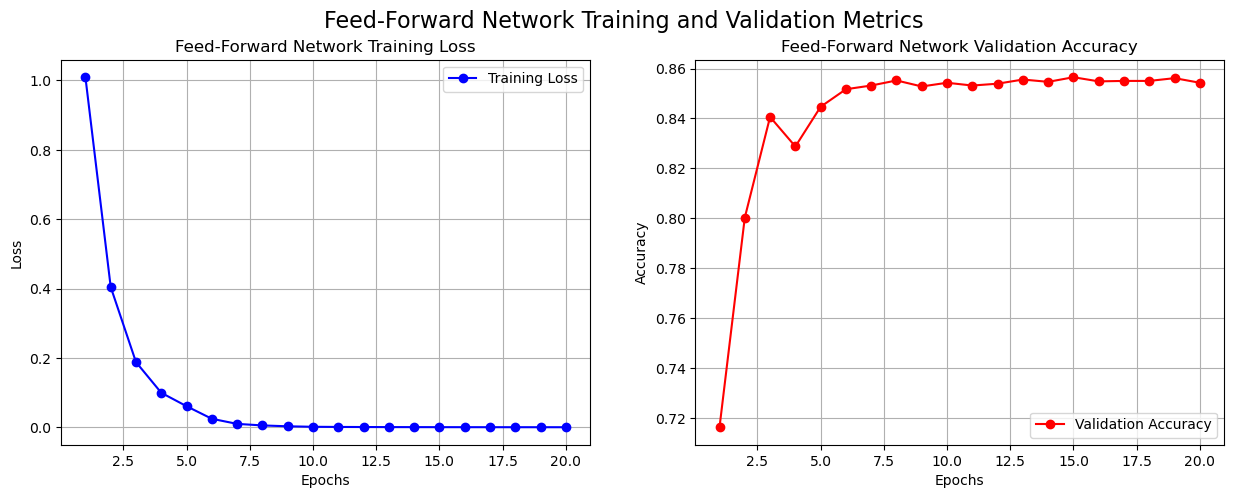

In [13]:
def plot_history(train_losses, val_accuracies, title_prefix=""):
    epochs = range(1, len(train_losses) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot Training Loss
    ax1.plot(epochs, train_losses, 'bo-', label='Training Loss')
    ax1.set_title(f'{title_prefix} Training Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.grid(True)
    ax1.legend()
    
    # Plot Validation Accuracy
    ax2.plot(epochs, val_accuracies, 'ro-', label='Validation Accuracy')
    ax2.set_title(f'{title_prefix} Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.grid(True)
    ax2.legend()
    
    plt.suptitle(f'{title_prefix} Training and Validation Metrics', fontsize=16)
    plt.show()

plot_history(train_losses, val_accuracies, title_prefix="Feed-Forward Network")

# 5 模型预测

In [14]:
# 加载资源
vocab_path = os.path.join(hparams["output_dir"], 'vocab.json')
with open(vocab_path, 'r', encoding='utf-8') as f:
    loaded_vocab = json.load(f)

labels_path = os.path.join(hparams["output_dir"], 'label_map.json')
with open(labels_path, 'r', encoding='utf-8') as f:
    label_map_loaded = json.load(f)

print(label_map_loaded)
# 实例化推理组件
inference_tokenizer = Tokenizer(vocab=loaded_vocab)
inference_model = TextClassificationModel(
    len(inference_tokenizer),
    hparams["embedding_dim"], 
    hparams["hidden_dim"], 
    len(label_map_loaded)
).to(hparams["device"])

model_path = os.path.join(hparams["output_dir"], "best_model.pth")
inference_model.load_state_dict(torch.load(model_path, map_location=hparams["device"]))

{'alt.atheism': 0, 'comp.graphics': 1, 'sci.med': 2, 'soc.religion.christian': 3}


<All keys matched successfully>

In [15]:
inference_model = model.eval()
predictor = Predictor(
    inference_model, 
    inference_tokenizer, 
    label_map_loaded, 
    hparams["device"]
)

# 预测
new_text = "The doctor prescribed a new medicine for the patient's illness, focusing on its gpu accelerated healing properties."
predicted_class = predictor.predict(new_text)

{"text": new_text, "pred": predicted_class}

{'text': "The doctor prescribed a new medicine for the patient's illness, focusing on its gpu accelerated healing properties.",
 'pred': 'sci.med'}